## RNN Model Building LSTM (Long Short-Term Memory)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import edf

original_df, _, _, _, _ = edf.get_data_for_modeling()

d:\machinelearning project\edf.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [ ]:
# Prepare the data for LSTM model (Multivariate)
features = original_df.columns.tolist()
target = 'Demand'
feature_cols = [c for c in features if c != target]

data = original_df[feature_cols + [target]].values
training_data_len = int(np.ceil(len(data) * 0.8))

# Preprocessing: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

train_data = scaled_data[0:training_data_len, :]

X_train = []
Y_train = []

# Create a sliding window of 24 hours to predict the next hour's demand
for i in range(24, len(train_data)):
    X_train.append(train_data[i-24:i, :-1]) # All columns except last (target)
    Y_train.append(train_data[i, -1])     # Last column (target)

X_train, Y_train = np.array(X_train), np.array(Y_train)
# X_train shape: (samples, time_steps, features)

In [ ]:
# Building the LSTM model
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model.summary()
model.compile(optimizer='adam', loss='mae', metrics=[keras.metrics.RootMeanSquaredError()])

history = model.fit(X_train, Y_train, epochs=20, batch_size=32, validation_split=0.1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,169 (278.00 KB)

 Trainable params: 71,169 (278.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - loss: 0.1740 - root_mean_squared_error: 0.2472 - val_loss: 0.1315 - val_root_mean_squared_error: 0.1672
Epoch 2/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.1345 - root_mean_squared_error: 0.1730 - val_loss: 0.1778 - val_root_mean_squared_error: 0.2267
Epoch 3/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - loss: 0.1321 - root_mean_squared_error: 0.1711 - val_loss: 0.1215 - val_root_mean_squared_error: 0.1532
Epoch 4/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 0.1272 - root_mean_squared_error: 0.1632 - val_loss: 0.1419 - val_root_mean_squared_error: 0.1774
Epoch 5/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 0.1257 - root_mean_squared_error: 0.1616 - val_loss: 0.1272 - val_root_mean_squared_error: 0.1597
Epoch 6/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - loss: 0.1231 - root_mean_squared_error: 0.1594 - val_loss: 0.1204 - val_root_mean_squared_error: 0.1527
Epoch 7/20
983/983 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Prepare the test data
test_data = scaled_data[training_data_len - 24:, :]
X_test = []
Y_actual = original_df[target].values[training_data_len:]
Y_actual = Y_actual.reshape(-1, 1)

for i in range(24, len(test_data)):
    X_test.append(test_data[i-24:i, :-1])

X_test = np.array(X_test)

# Make predictions
predictions = model.predict(X_test)

# To inverse transform the prediction, we need to provide the same shape as scaled_data
# We'll create a dummy array for this purpose
dummy = np.zeros((len(predictions), data.shape[1]))
dummy[:, -1] = predictions.flatten()
inverse = scaler.inverse_transform(dummy)
predictions = inverse[:, -1].reshape(-1, 1)

# Evaluating the LSTM model
mae_lstm = mean_absolute_error(Y_actual, predictions)
rmse_lstm = np.sqrt(mean_squared_error(Y_actual, predictions))
r2_lstm = r2_score(Y_actual, predictions)
mape_lstm = np.mean(np.abs((Y_actual - predictions) / Y_actual)) * 100
mne_lstm = np.mean(edf.calculate_normalized_error(Y_actual, predictions.flatten()))

print('LSTM RMSE:', rmse_lstm)
print('LSTM MAE:', mae_lstm)
print('LSTM R^2 Score (Accuracy):', r2_lstm)
print(f'LSTM MAPE: {mape_lstm:.2f}%')
print(f'LSTM Mean Normalized Error (0-1): {mne_lstm:.4f}')

# Calculate Confidence Interval (95%)
residuals = Y_actual - predictions
std_residuals = np.std(residuals)
confidence_interval = 1.96 * std_residuals
print(f'LSTM 95% Confidence Interval: +/- {confidence_interval:.2f}')

273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
LSTM RMSE: 222.59812773600785
LSTM MAE: 167.07728462289506
LSTM R^2 Score (Accuracy): 0.9751716195943579
LSTM MAPE: 3.64%
LSTM 95% Confidence Interval: +/- 431.33


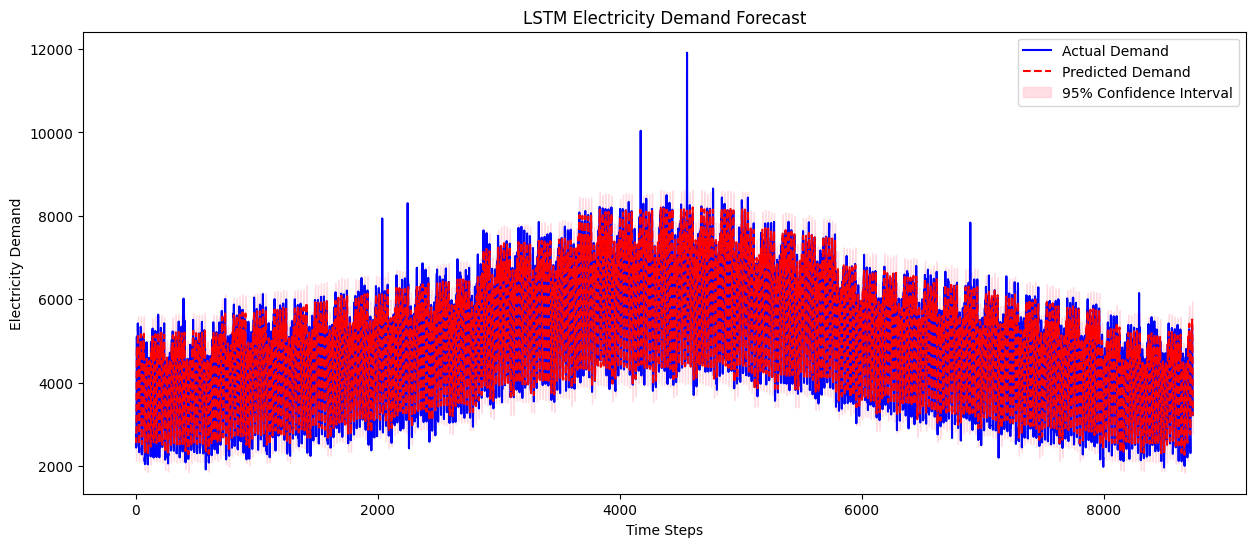

In [ ]:
# Visualize the predictions vs actual values
plt.figure(figsize=(15,6))
plt.plot(range(len(Y_actual)), Y_actual, label='Actual Demand', color='blue')
plt.plot(range(len(predictions)), predictions, label='Predicted Demand', color='Red', linestyle='--')
plt.fill_between(range(len(predictions)), 
                 (predictions.flatten() - confidence_interval), 
                 (predictions.flatten() + confidence_interval), 
                 color='pink', alpha=0.5, label='95% Confidence Interval')
plt.title("LSTM Electricity Demand Forecast")
plt.xlabel("Time Steps")
plt.ylabel("Electricity Demand")
plt.legend()
plt.show()